BINF 5507: ML/AI in Clinical Bioinformatics
Assignment 2: Supervised Learning
Author: Blair Steele 
Date: June 24, 2026

<!-- # Run in Terminal
# cd "/Users/BGS/Desktop/🧬 CLINICAL BIOINFORMATICS - HUMBER (LU = Dec.4.2025)/★ SCHOOL/★ SEMESTER 2/BINF 5507 - Machine Learning and AI for Bioinformatics/ASSIGNMENTS/Assignment #2/assignment-2-supervised-learning-blairgsteele" 
# git clone https://github.com/ml-binf-5507/assignment-2-supervised-learning-blairgsteele.git
# cd assignment-2-supervised-learning-blairgsteele #run in terminal -->

In [1]:
#Set path of Jupyter library to the class repository
import sys

sys.path.append(
    "/Users/BGS/Desktop/🧬 CLINICAL BIOINFORMATICS - HUMBER (LU = Dec.4.2025)/★ SCHOOL/★ SEMESTER 2/BINF 5507 - Machine Learning and AI for Bioinformatics/ASSIGNMENTS/Assignment #2/assignment-2-supervised-learning-blairgsteele"
)

In [2]:
# Import Libraries 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import r2_score, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
import seaborn as sns

# Import implementations
from students import data_processing, regression, classification, evaluation

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


# Set up new virtual environment (Run in terminal)

# create new virtual environment
python3 -m venv binf5507_asgmt_2_env

# activate env
source binf5507_asgmt_2_env/bin/activate

# install the required packages from "requirements.txt" file in repo
pip install -r requirements.txt

## Step 2: Load and Preprocess Data

In [3]:
# Load & Preprocess the Data
heart_data_path = "/Users/BGS/Desktop/🧬 CLINICAL BIOINFORMATICS - HUMBER (LU = Dec.4.2025)/★ SCHOOL/★ SEMESTER 2/BINF 5507 - Machine Learning and AI for Bioinformatics/ASSIGNMENTS/Assignment #2/heart_disease_uci.csv"

df = data_processing.load_heart_disease_data(heart_data_path)
print(f"Loaded data shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Missing values:\n{df.isnull().sum().sum()} total missing")

# Preprocess
df_clean = data_processing.preprocess_data(df)
print(f"\nPreprocessed data shape: {df_clean.shape}")
print(f"Data types: {df_clean.dtypes.unique}")


Loaded data shape: (920, 15)
Columns: ['age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']
Missing values:
1759 total missing

Preprocessed data shape: (920, 22)
Data types: <bound method Series.unique of age                           int64
trestbps                    float64
chol                        float64
thalch                      float64
oldpeak                     float64
ca                          float64
num                           int64
sex_Male                      int64
dataset_Hungary               int64
dataset_Switzerland           int64
dataset_VA Long Beach         int64
cp_atypical angina            int64
cp_non-anginal                int64
cp_typical angina             int64
fbs_True                      int64
restecg_normal                int64
restecg_st-t abnormality      int64
exang_True                    int64
slope_flat                    int64
slope_upsloping               int6

/Users/BGS/Desktop/🧬 CLINICAL BIOINFORMATICS - HUMBER (LU = Dec.4.2025)/★ SCHOOL/★ SEMESTER 2/BINF 5507 - Machine Learning and AI for Bioinformatics/ASSIGNMENTS/Assignment #2/assignment-2-supervised-learning-blairgsteele/students/data_processing.py:71: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])


## Task 1: Linear Regression with ElasticNet

Regression data shapes: X=(920, 20), y=(920,)
Train shape: (736, 20), Test shape: (184, 20)

Training ElasticNet grid search...
Grid search results shape: (9, 4)
R² range: 0.489 to 0.585


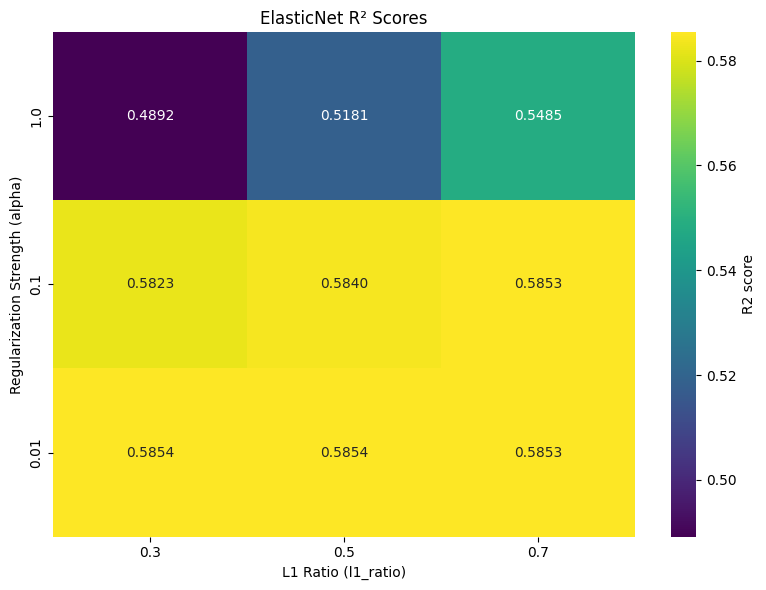


Best ElasticNet:
  l1_ratio: 0.7
  alpha: 0.1
  Test R²: 0.531


In [4]:
# Prepare regression data 
X_reg, y_reg = data_processing.prepare_regression_data(df_clean, target="chol")
print(f"Regression data shapes: X={X_reg.shape}, y={y_reg.shape}")

# Split and scale
X_train_reg, X_test_reg, y_train_reg, y_test_reg, scaler_reg = data_processing.split_and_scale(
    X_reg, y_reg, test_size=0.2, random_state=42
)
print(f"Train shape: {X_train_reg.shape}, Test shape: {X_test_reg.shape}")

#Train ElasticNet with grid search
print("\nTraining ElasticNet grid search...")
results = regression.train_elasticnet_grid(
    X_train_reg, y_train_reg,
    l1_ratios=[0.3, 0.5, 0.7],
    alphas=[0.01, 0.1, 1.0]
)
print(f"Grid search results shape: {results.shape}")
print(f"R² range: {results['r2_score'].min():.3f} to {results['r2_score'].max():.3f}")

#Plot heatmap
fig = regression.create_r2_heatmap(
    results,
    [0.3, 0.5, 0.7],
    [0.01, 0.1, 1.0]
)
plt.title('ElasticNet R² Scores')
plt.tight_layout()
plt.show()

#Get best model
reg_best = regression.get_best_elasticnet_model(
    X_train_reg, y_train_reg, X_test_reg, y_test_reg,
    l1_ratios=[0.3, 0.5, 0.7],
    alphas=[0.1, 0.1, 1.0]
)
print(f"\nBest ElasticNet:")
print(f"  l1_ratio: {reg_best['best_l1_ratio']}")
print(f"  alpha: {reg_best['best_alpha']}")
print(f"  Test R²: {reg_best['test_r2']:.3f}")



## Tasks 2-3: Classification with Logistic Regression and k-NN

In [5]:
# Prepare classification data
X_clf, y_clf = data_processing.prepare_classification_data(df_clean, target='num') #num = the number of narrowed major vessels found during coronary angiography
print(f"Classification data shapes: X={X_clf.shape}, y={y_clf.shape}")

# Split and scale (80/20 train/test split)
X_train_clf, X_test_clf, y_train_clf, y_test_clf, scaler_clf = data_processing.split_and_scale(
    X_clf, y_clf, test_size=0.2, random_state=42
)
print(f"\nTrain shape: {X_train_clf.shape}, Test shape: {X_test_clf.shape}")

Classification data shapes: X=(920, 20), y=(920,)

Train shape: (736, 20), Test shape: (184, 20)


* X=(920, 20) = feature matrix  
    - 920 rows (patients)
    - 20 columns (features used to make predictions)

* y=(920,) = target vector
    - 930 (binary outcome column aka 'num' = indicates if patient has heart disease or not. Corresponds to 920 patients)


* 80/20 train/test split: Patients are split into 80% training set and 20% testing set
    - Train shape: (736, 20) - 736 is 80% of 920 = training set
    - Test shape: (184, 20) - 184 = 20% testing set

### Logistic Regression - AUROC Curve

Training Logistic Regression grid search...


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin

Best parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}

Logistic Regression Test AUC: 0.905


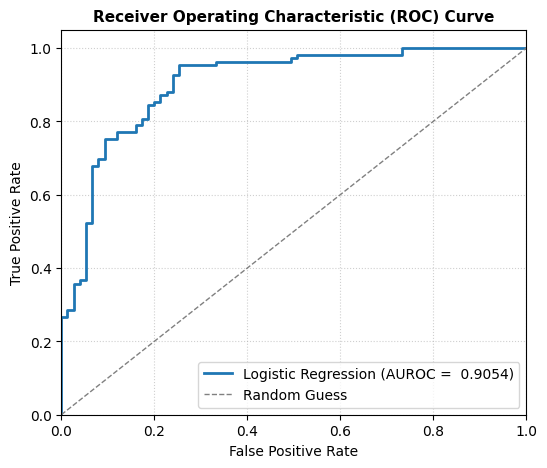

In [6]:
#Train logistic regression
print("Training Logistic Regression grid search...")
lr_best = classification.get_best_logistic_regression(
    X_train_clf, y_train_clf, X_test_clf, y_test_clf
)
print(f"Best parameters: {lr_best['best_params']}")
print(f"\nLogistic Regression Test AUC: {lr_best['test_auc']:.3f}")

# Get probability predictions for curves
y_pred_proba_log = lr_best['model'].predict_proba(X_test_clf)[:, 1]

# Plot AUROC curve
fig_lr, ax_lr = evaluation.generate_auroc_curve(
    y_test_clf, y_pred_proba_log, model_name='Logistic Regression'
    )
plt.show()

### Logistic Regression - AUPRC Curve

Training Logistic Regression grid search...


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin

Best parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}

Logistic Regression Test AUC: 0.905
Logistic Regression Test AUPRC: 0.925


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


(0.0, 1.05)

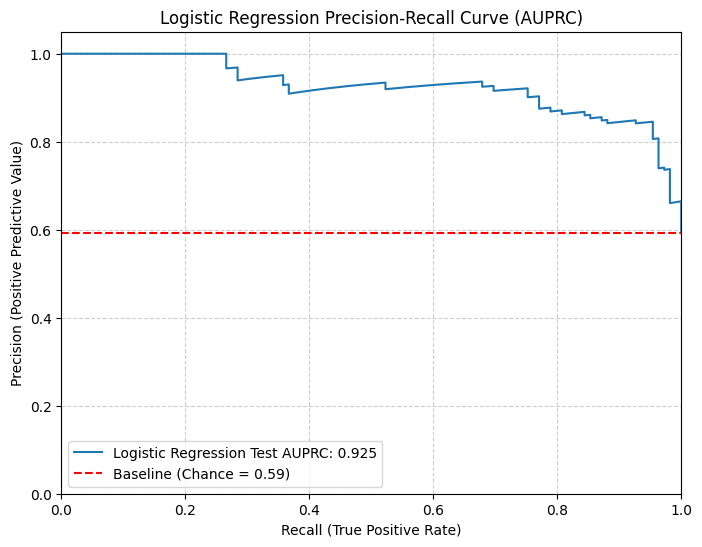

In [18]:
from sklearn.metrics import precision_recall_curve, auc

#Train logistic regression
print("Training Logistic Regression grid search...")
lr_best = classification.get_best_logistic_regression(
    X_train_clf, y_train_clf, X_test_clf, y_test_clf
)
print(f"Best parameters: {lr_best['best_params']}")
print(f"\nLogistic Regression Test AUC: {lr_best['test_auc']:.3f}")

# Get probability predictions for curves
y_pred_proba_log = lr_best['model'].predict_proba(X_test_clf)[:, 1]

# Calculate precision & recall
precision, recall, _ = precision_recall_curve(y_test_clf, y_pred_proba_log)

# Calculate AUPRC score
auprc_score = auc(recall,precision)
print(f"Logistic Regression Test AUPRC: {auprc_score:.3f}")

# Plot AUPRC curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f"Logistic Regression Test AUPRC: {auprc_score:.3f}")

# Plot baseline
baseline = sum(y_test_clf)/ len(y_test_clf)
plt.axhline(y=baseline, color='red', linestyle='--', label=f'Baseline (Chance = {baseline:.2f})')

# Format plot
plt.xlabel('Recall (True Positive Rate)')
plt.ylabel('Precision (Positive Predictive Value)')
plt.title('Logistic Regression Precision-Recall Curve (AUPRC)')
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

### k-NN Classification - AUROC Curve

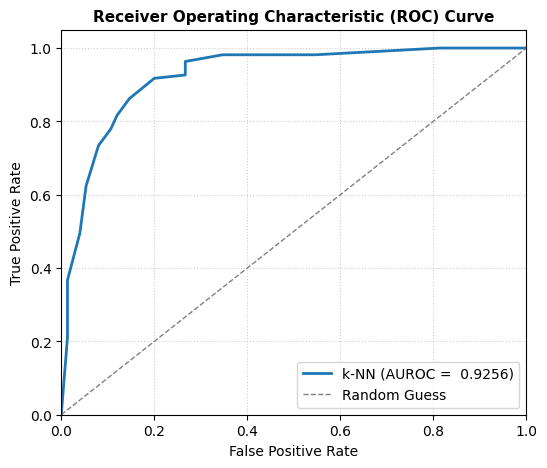


k-NN Model Summary
Best k (n_neighhours): 15
Best Parameters: {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'uniform'}
k-NN Test AUC: 0.926


In [7]:
#train and get results of k-NN dictionary
knn_results = classification.get_best_knn(
    X_train_clf, y_train_clf, X_test_clf,
    y_test_clf
)

#extract predicted probabilities
y_pred_proba_knn = knn_results['model'].predict_proba(X_test_clf)[:, 1]

fig_knn, ax_knn = evaluation.generate_auroc_curve(
    y_test_clf, y_pred_proba_knn, model_name='k-NN'
)

plt.show()

#ptin k-NNN summary results
print("\n" + "="*60)
print("k-NN Model Summary")
print("="*60)
print(f"Best k (n_neighhours): {knn_results['best_k']}")
print(f"Best Parameters: {knn_results['best_params']}")
print(f"k-NN Test AUC: {knn_results['test_auc']:.3f}")
print("="*60)

### k-NN Classification - AUPRC Curve

k-NN Test AUPRC: 0.937


(0.0, 1.05)

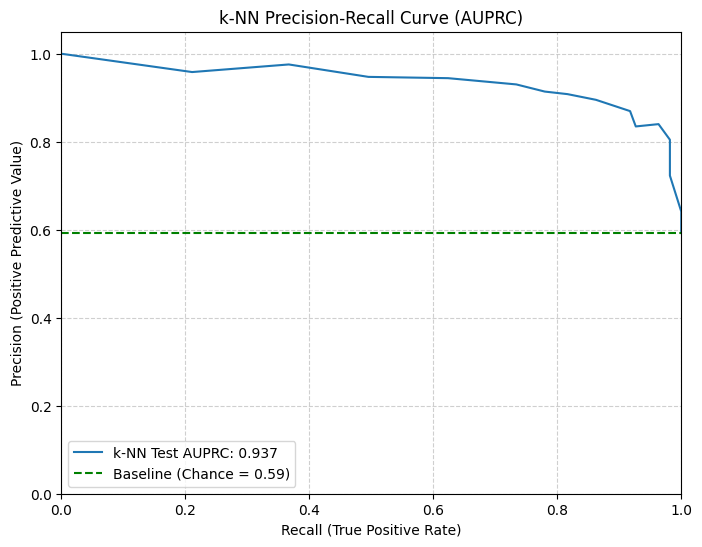

In [17]:
# Calculate precision & recall
precision_knn, recall_knn, _ = precision_recall_curve(y_test_clf, y_pred_proba_knn)

# Calculate AUPRC score
auprc_score_knn = auc(recall_knn,precision_knn)
print(f"k-NN Test AUPRC: {auprc_score_knn:.3f}")

# Plot AUPRC curve
plt.figure(figsize=(8, 6))
plt.plot(recall_knn, precision_knn, label=f"k-NN Test AUPRC: {auprc_score_knn:.3f}")

# Plot baseline
baseline = sum(y_test_clf)/ len(y_test_clf)
plt.axhline(y=baseline, color='green', linestyle='--', label=f'Baseline (Chance = {baseline:.2f})')

# Format plot
plt.xlabel('Recall (True Positive Rate)')
plt.ylabel('Precision (Positive Predictive Value)')
plt.title('k-NN Precision-Recall Curve (AUPRC)')
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

## Task 4: Model Comparison

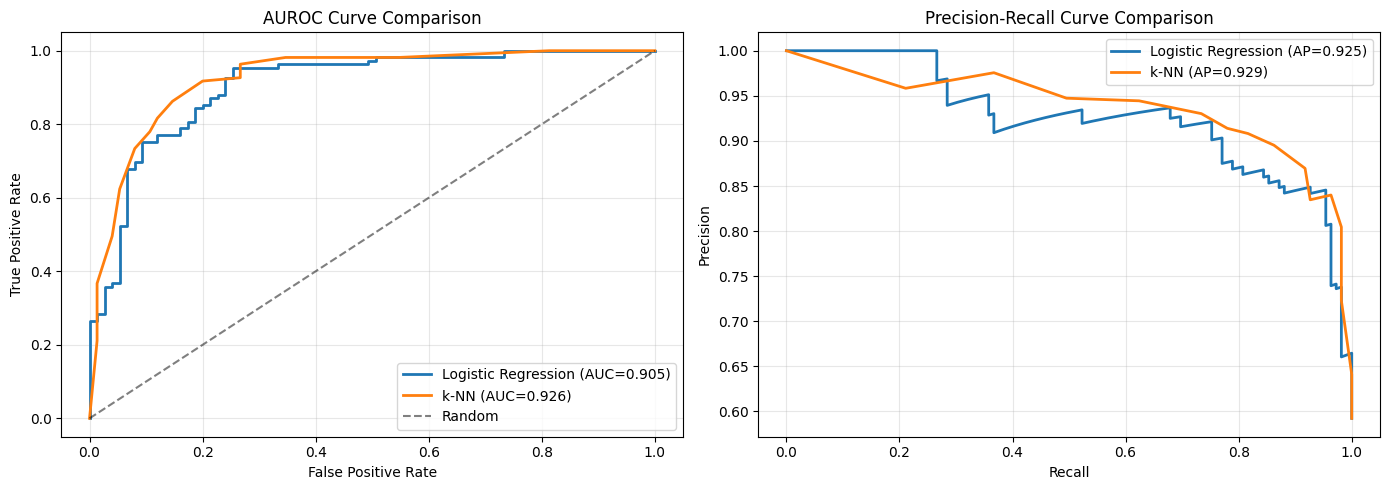


MODEL COMPARISON SUMMARY
Logistic Regression:
  AUROC: 0.905
  AUPRC: 0.925

k-NN:
  AUROC: 0.926
  AUPRC: 0.929

Better model: k-NN


In [21]:
# Compare AUROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AUROC comparison
fpr_lr, tpr_lr, _ = roc_curve(y_test_clf, y_pred_proba_log)
aur_lr = roc_auc_score(y_test_clf, y_pred_proba_log)
fpr_knn, tpr_knn, _ = roc_curve(y_test_clf, y_pred_proba_knn)
auc_knn = roc_auc_score(y_test_clf, y_pred_proba_knn)

axes[0].plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc_lr:.3f})', linewidth=2)
axes[0].plot(fpr_knn, tpr_knn, label=f'k-NN (AUC={auc_knn:.3f})', linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', label='Random', alpha=0.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('AUROC Curve Comparison')
axes[0].legend()
axes[0].grid(alpha=0.3)

# PR comparison
precision_lr, recall_lr, _ = precision_recall_curve(y_test_clf, y_pred_proba_log)
ap_lr = average_precision_score(y_test_clf, y_pred_proba_log)
precision_knn, recall_knn, _ = precision_recall_curve(y_test_clf, y_pred_proba_knn)
ap_knn = average_precision_score(y_test_clf, y_pred_proba_knn)

axes[1].plot(recall_lr, precision_lr, label=f'Logistic Regression (AP={ap_lr:.3f})', linewidth=2)
axes[1].plot(recall_knn, precision_knn, label=f'k-NN (AP={ap_knn:.3f})', linewidth=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve Comparison')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Summary
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(f"Logistic Regression:")
print(f"  AUROC: {auc_lr:.3f}")
print(f"  AUPRC: {ap_lr:.3f}")
print(f"\nk-NN:")
print(f"  AUROC: {auc_knn:.3f}")
print(f"  AUPRC: {ap_knn:.3f}")
print(f"\nBetter model: {'Logistic Regression' if auc_lr > auc_knn else 'k-NN'}")
print("="*60)

In [ ]:
# #push changes to github classroom

# # 1. Stage all changed files (including your notebook and AI disclosure)
# git add BINF_5507_Assignment_2_Blair_Jun_25_2026.ipynb AI_DISCLOSURE.md

# # 2. Commit the changes with a descriptive message
# git commit -m "Completed models, fixed task 4 bug, and added AI disclosure"

# # 3. Push the work to your GitHub Classroom repository
# git push origin main